- O PCA atuará como o baseline de redução. Por ser um algoritmo linear, ele tenta traçar eixos (os Componentes Principais) que capturem a maior variação possível dos dados. Se os times da NFL seguirem uma lógica matemática razoavelmente reta, os campeões serão vistos isolados em um quadrante específico.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# carregamento dos dados
df_season = pd.read_parquet("dados_reducao.parquet")

# preparação e padronização
# usando as exatas variáveis que se provaram úteis nos notebooks anteriores(EDA, regras de associação, e outliers)
features = ['PF', 'PA', 'Off_Pass_Yds', 'Off_Rush_Yds', 'Off_Carries', 
            'Off_Turnovers', 'Def_Sacks_Produced', 'Def_Turnovers_Forced']

X = df_season[features]

# o PCA é extremamente sensível à escala. Sem isso, as Jardas dominariam os Sacks.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# aplicação do PCA --> reduzindo 8 dimensões pra apenas 2.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_season['PCA1'] = X_pca[:, 0]
df_season['PCA2'] = X_pca[:, 1]

In [6]:
# quanta informação original foi salva nessas duas dimensões?
var_explicada = pca.explained_variance_ratio_
print(f"Variância Retida no Eixo X (PC1): {var_explicada[0]*100:.2f}%")
print(f"Variância Retida no Eixo Y (PC2): {var_explicada[1]*100:.2f}%")
print(f"Total da informação original preservada: {sum(var_explicada)*100:.2f}%\n")

Variância Retida no Eixo X (PC1): 36.57%
Variância Retida no Eixo Y (PC2): 22.48%
Total da informação original preservada: 59.05%



- Ter um total da informação original preservada de 59.05%, é apenas mediano na ciência de dados, indicando uma inadequação desse algoritmo linear.

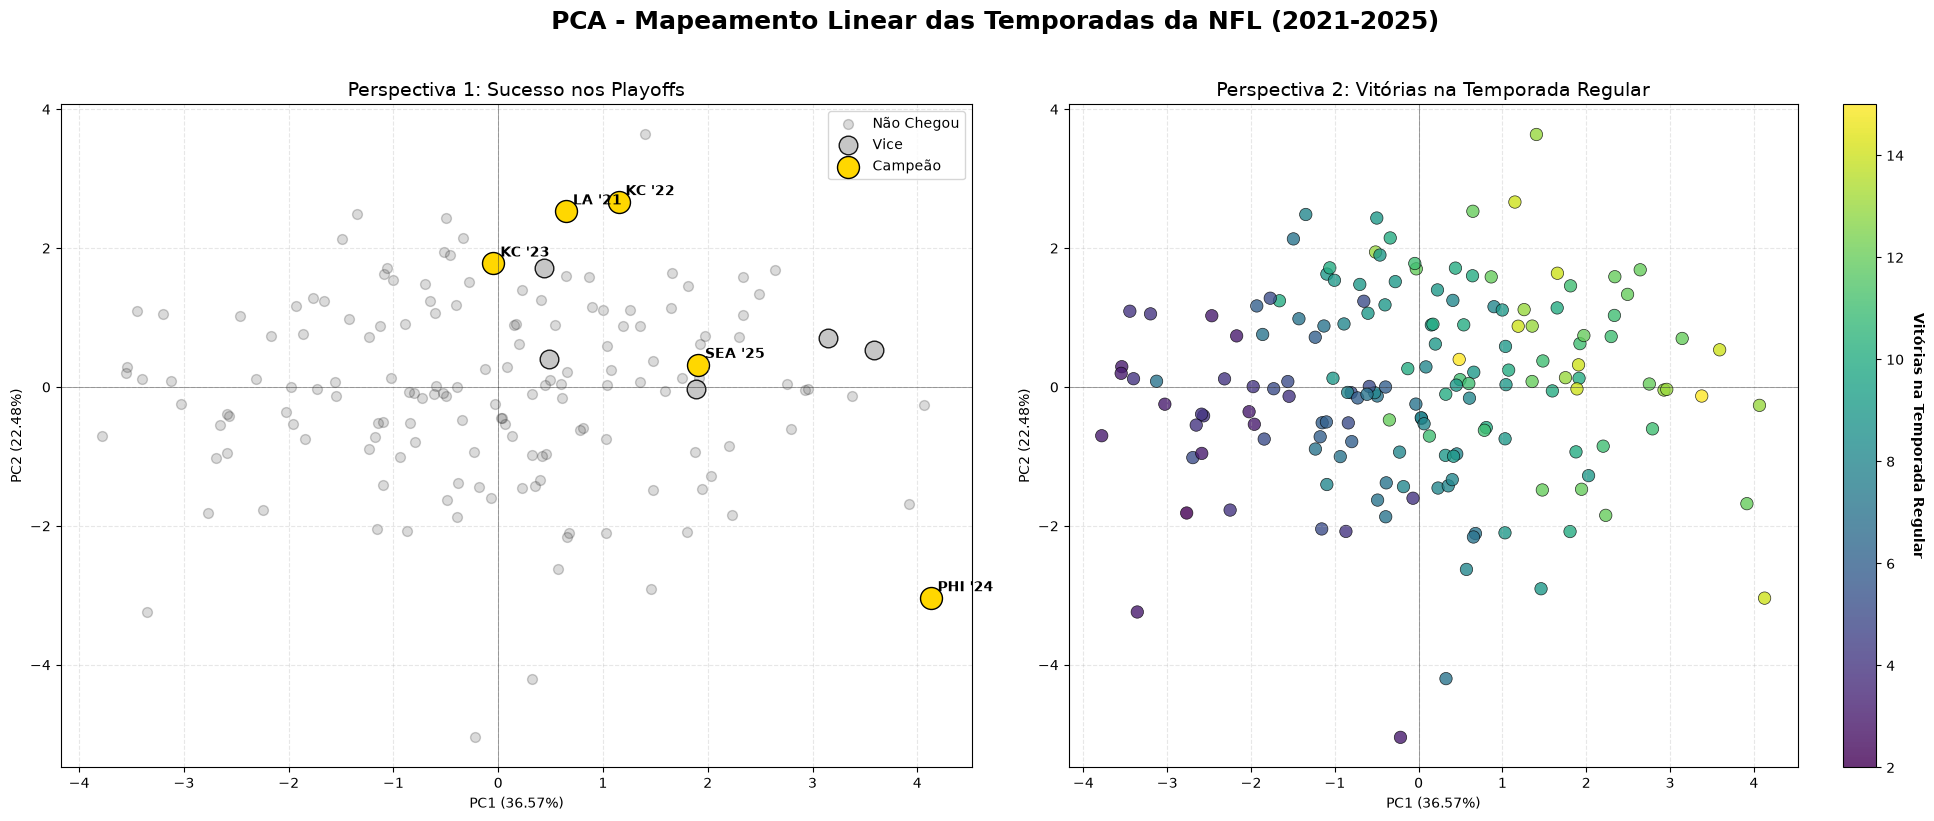

In [7]:
# visualização (mapa do universo da NFL nos ultimos 5 anos)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.suptitle('PCA - Mapeamento Linear das Temporadas da NFL (2021-2025)', fontsize=18, fontweight='bold', y=1.02)

# --- Gráfico 1: Status Super Bowl (O Clássico) ---
cores = {'Campeão': '#FFD700', 'Vice': '#C0C0C0', 'Não Chegou': '#4a4a4a', '-': '#4a4a4a'}
tamanhos = {'Campeão': 250, 'Vice': 180, 'Não Chegou': 50, '-': 50}
alphas = {'Campeão': 1.0, 'Vice': 0.9, 'Não Chegou': 0.2, '-': 0.2}

for status in ['-', 'Não Chegou', 'Vice', 'Campeão']:
    subset = df_season[df_season['Status_SB'] == status]
    if not subset.empty:
        ax1.scatter(subset['PCA1'], subset['PCA2'], c=cores[status], s=tamanhos[status], 
                    alpha=alphas[status], label=status, edgecolors='black', linewidth=1)

campeoes = df_season[df_season['Status_SB'] == 'Campeão']
for idx, row in campeoes.iterrows():
    ax1.annotate(f"{row['team']} '{str(row['season'])[-2:]}", (row['PCA1'], row['PCA2']),
                 xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax1.set_title('Perspectiva 1: Sucesso nos Playoffs', fontsize=14)
ax1.set_xlabel(f'PC1 ({var_explicada[0]*100:.2f}%)')
ax1.set_ylabel(f'PC2 ({var_explicada[1]*100:.2f}%)')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.5, alpha=0.5)

# --- Gráfico 2: Vitórias na Temporada (Mapa de Calor) ---
# usando o colormap 'viridis' (escuro = poucas vitórias, amarelo = muitas vitórias)
scatter_wins = ax2.scatter(df_season['PCA1'], df_season['PCA2'], 
                           c=df_season['Reg_Season_Wins'], cmap='viridis', 
                           s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

# adicionando a barra de cores lateral
cbar = plt.colorbar(scatter_wins, ax=ax2)
cbar.set_label('Vitórias na Temporada Regular', rotation=270, labelpad=15, fontweight='bold')

ax2.set_title('Perspectiva 2: Vitórias na Temporada Regular', fontsize=14)
ax2.set_xlabel(f'PC1 ({var_explicada[0]*100:.2f}%)')
ax2.set_ylabel(f'PC2 ({var_explicada[1]*100:.2f}%)')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax2.axvline(0, color='black', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

- O gráfico sob a perspectiva de vitórias na temporada regular revela o que era procurado: um degradê de visualização e ordem clara. O PCA não sabe em sua execução quantas vitórias cada time teve, ele apenas olhou para os números de campo (jardas, sacks, carries, turnovers) e os organizou matematicamente. O resultado visual indica que as variáveis que escolhemos ditam razoavelmente o sucesso na liga.

- O Eixo X (PC1) parece ser o "Eixo da Competência": nota-se como a transição de cores é quase que puramente horizontal. Os times roxos e escuros (2 a 6 vitórias) estão todos espremidos à esquerda (PC1 negativo). Os times amarelos e verde-claros (12 a 15 vitórias) dominam a direita (PC1 positivo). Isso significa que as métricas, quando combinadas no Componente 1, são um termômetro hábil para medir se um time é vencedor na temporada regular.

- O Eixo Y (PC2) parece ser o "Eixo do Estilo/Anomalia": O eixo vertical não define vitórias (temos bolinhas amarelas e verdes no topo, no meio, e lá embaixo). Pode ser que ele separe como o time joga. E vendo aquele ponto amarelo solitário no extremo inferior direito (PC1 altíssimo, PC2 absurdamente negativo): se trata do Philadelphia Eagles de 2024. O modelo linear não soube o que fazer com uma defesa tão anômala e jogou o time para fora do enxame principal.

- Aqui está um dos problemáticas da redução de dimensionalidade, que é a incerteza do que exatamente os eixos representam, então tornando a interpretação mais complexa.

- Tentando verificar a análise realizada:

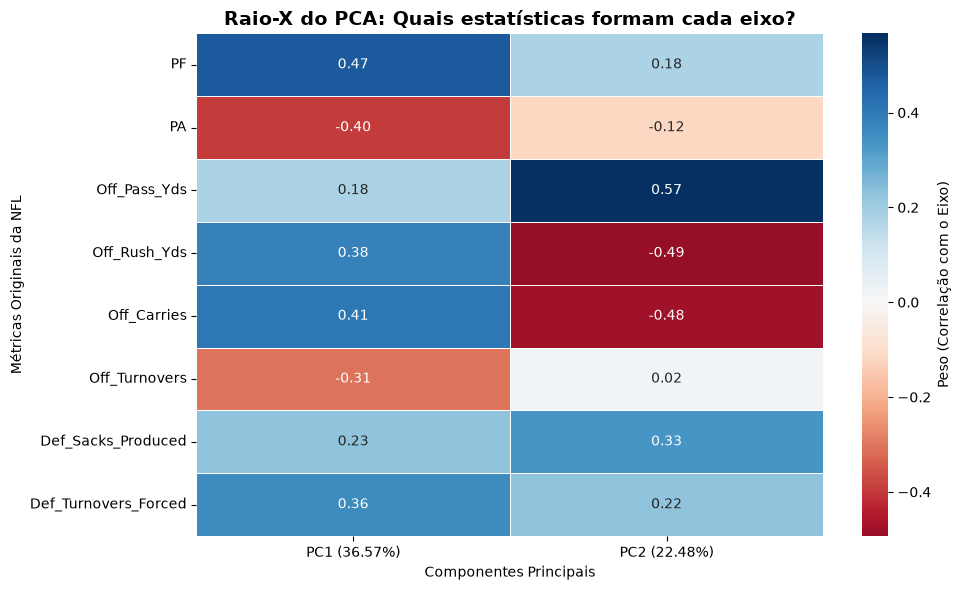

In [8]:
# explicabilidade
# pca.components_ contém os pesos exatos que o algoritmo usou para criar PC1 e PC2
pesos = pca.components_.T

# criando um DataFrame para facilitar a visualização
df_pesos = pd.DataFrame(pesos, columns=['PC1 (36.57%)', 'PC2 (22.48%)'], index=features)

# plotando o Heatmap de pesos
plt.figure(figsize=(10, 6))
sns.heatmap(df_pesos, annot=True, cmap='RdBu', center=0, fmt='.2f', 
            linewidths=0.5, cbar_kws={'label': 'Peso (Correlação com o Eixo)'})

plt.title('Raio-X do PCA: Quais estatísticas formam cada eixo?', fontsize=14, fontweight='bold')
plt.xlabel('Componentes Principais')
plt.ylabel('Métricas Originais da NFL')
plt.tight_layout()
plt.show()

- PC1: O Eixo do "Time Bom" (Qualidade / Eficiência)
    - O PCA identificou o que faz um time vencer na temporada regular. Tudo que é positivo no esporte empurra o time para a direita no gráfico: marcar pontos (PF: 0.47), correr bem com a bola (Off_Carries: 0.41, e Off_Rush_Yds: 0.38) e forçar turnovers (Def_Turnovers_Forced: 0.36). Tudo que destrói um time empurra para a esquerda: sofrer pontos (PA: -0.40) e entregar a bola (Off_Turnovers: -0.31). Foi essa combinação que gerou aquele degradê de vitórias no gráfico da perspectiva 2.

- PC2: O Eixo da "Identidade" (Aéreo vs. Terrestre)
    - Esse é o grande achado da matriz, o Componente 2 não liga para quem vence ou perde; ele mede como o time joga. Olhando para o contraste das cores: as jardas aéreas (Off_Pass_Yds: 0.57) puxam violentamente para cima (azul escuro). Em oposição direta, as jardas terrestres (Off_Rush_Yds: -0.49) e as corridas (Off_Carries: -0.48) puxam com a mesma força para baixo (vermelho escuro).
    - No eixo Y dos gráficos, times no topo são os do estilo Air Raid (que passam a bola o tempo todo), e times na parte inferior são do estilo Ground and Pound (esmagam no jogo corrido).
    - Isso explica que a presença do Eagles de 2024 lá em baixo não era por sua característica como outlier defensivo histórico, mas sim pela natureza do seu ataque, que era sim totalmente focado na corrida, em que o RB Saquon Barkley teve a melhor temporada de sua carreira.

- Sabendo agora o que o eixo Y representa, a presença dos tres ganhadores: LA 21, KC 22, e KC 23, relativamente concentrados na parte de cima é explicada, esses tres times foram times liderados em performance aérea por seus quarterbacks, sendo temporadas de muito prestígio pra QBs históricos, que são Matt Stafford e, aquele que alguns consideram o melhor de todos os tempos, Patrick Mahomes.